# CReST: Domain Profiles Beyond Overall Proficiency

Tests domain-relative information beyond official overall PISA Creative Thinking proficiency using frozen hidden-target representations.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Environment and locked analysis protocol

from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error


BASE_DIR = Path.cwd()

HANDOFF_DIR = (
    BASE_DIR
    / "processed"
    / "crest_v5_handoff"
)

RESULTS_DIR = (
    BASE_DIR
    / "results"
)

FIG_DIR = (
    BASE_DIR
    / "figures"
)

PROFILE_DIR = (
    RESULTS_DIR
    / "profile_beyond_overall_proficiency"
)

PROFILE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


primary_meta = pd.read_pickle(
    HANDOFF_DIR
    / "primary_meta.pkl"
)

analysis_pv_df = pd.read_pickle(
    RESULTS_DIR
    / "survey_weighted_population"
    / "crest_population_with_creative_pvs.pkl"
)


CREATIVE_PV_COLS = [
    f"PV{i}CRTH_NC"
    for i in range(
        1,
        11
    )
]


DOMAIN_ORDER = [
    "Written",
    "Visual",
    "Social",
    "Scientific"
]


print(
    "Primary cohort:",
    len(primary_meta)
)

print(
    "Population/PV cohort:",
    len(analysis_pv_df)
)

print(
    "Systems:",
    analysis_pv_df["CNT"].nunique()
)

print(
    "Creative PVs:",
    len(CREATIVE_PV_COLS)
)

Primary cohort: 142564
Population/PV cohort: 140839
Systems: 63
Creative PVs: 10


In [ ]:
# Lock the residual-profile interpretation protocol

PROFILE_PROTOCOL = {

    "question":
        (
            "Does CReST retain domain-relative creative-performance "
            "information after conditioning on official overall "
            "PISA Creative Thinking proficiency?"
        ),

    "unit_of_generalization":
        "education system",

    "overall_proficiency":
        "10 official PISA Creative Thinking plausible values",

    "primary_target":
        (
            "domain-relative performance residual after removing "
            "within-system overall proficiency association"
        ),

    "representation":
        (
            "CReST domain-specific learned representation extracted "
            "with target items hidden"
        ),

    "probe_training":
        "validation systems only",

    "evaluation":
        "held-out unseen test systems",

    "uncertainty":
        "education-system bootstrap",

    "important_caution":
        (
            "This is conditional profile evidence, not independent "
            "external validity, because PISA PVs and domain outcomes "
            "originate from the same assessment."
        )
}


with open(
    PROFILE_DIR
    / "profile_analysis_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        PROFILE_PROTOCOL,
        f,
        indent=2
    )


for key, value in PROFILE_PROTOCOL.items():

    print(
        f"{key}: {value}"
    )

question: Does CReST retain domain-relative creative-performance information after conditioning on official overall PISA Creative Thinking proficiency?
unit_of_generalization: education system
overall_proficiency: 10 official PISA Creative Thinking plausible values
primary_target: domain-relative performance residual after removing within-system overall proficiency association
representation: CReST domain-specific learned representation extracted with target items hidden
probe_training: validation systems only
evaluation: held-out unseen test systems
uncertainty: education-system bootstrap
important_caution: This is conditional profile evidence, not independent external validity, because PISA PVs and domain outcomes originate from the same assessment.


In [ ]:
# Audit existing domain-specific result artifacts

all_result_files = sorted(
    RESULTS_DIR.rglob(
        "*domain*"
    )
)


print(
    "Domain-related artifacts found:",
    len(all_result_files)
)


for path in all_result_files:

    if path.is_file():

        print(
            path.relative_to(
                RESULTS_DIR
            )
        )

Domain-related artifacts found: 37
crest_AB_domain_process_composition.csv
crest_domain_increment_63system.csv
crest_domain_increment_7fold.csv
crest_domain_increment_bootstrap_ci.csv
crest_domain_increment_protocol.json
crest_domain_increment_summary.csv
crest_domain_process_transfer_63system.csv
crest_domain_process_transfer_7fold.csv
crest_domain_process_transfer_summary.csv
final_test_outputs\fold_0\domain_available.npy
final_test_outputs\fold_0\z_domain_creative.npy
final_test_outputs\fold_0\z_domain_shared.npy
final_test_outputs\fold_0\z_domain_specific.npy
final_test_outputs\fold_1\domain_available.npy
final_test_outputs\fold_1\z_domain_creative.npy
final_test_outputs\fold_1\z_domain_shared.npy
final_test_outputs\fold_1\z_domain_specific.npy
final_test_outputs\fold_2\domain_available.npy
final_test_outputs\fold_2\z_domain_creative.npy
final_test_outputs\fold_2\z_domain_shared.npy
final_test_outputs\fold_2\z_domain_specific.npy
final_test_outputs\fold_3\domain_available.npy
final

In [ ]:
# Recover the exact previously locked domain protocol

DOMAIN_PROTOCOL_FILE = (
    RESULTS_DIR
    / "crest_domain_increment_protocol.json"
)

DOMAIN_7FOLD_FILE = (
    RESULTS_DIR
    / "crest_domain_increment_7fold.csv"
)

DOMAIN_SYSTEM_FILE = (
    RESULTS_DIR
    / "crest_domain_increment_63system.csv"
)


with open(
    DOMAIN_PROTOCOL_FILE,
    "r",
    encoding="utf-8"
) as f:

    domain_protocol = json.load(
        f
    )


domain_7fold_existing = pd.read_csv(
    DOMAIN_7FOLD_FILE
)

domain_system_existing = pd.read_csv(
    DOMAIN_SYSTEM_FILE
)


print(
    "LOCKED DOMAIN PROTOCOL"
)

print(
    "=" * 72
)

for key, value in domain_protocol.items():

    print(
        f"{key}: {value}"
    )


print(
    "\n7-FOLD DOMAIN RESULT COLUMNS"
)

print(
    domain_7fold_existing.columns.tolist()
)


print(
    "\n7-FOLD DOMAIN RESULT SHAPE"
)

print(
    domain_7fold_existing.shape
)


print(
    "\nFIRST ROWS"
)

print(
    domain_7fold_existing
    .head()
    .to_string(
        index=False
    )
)


print(
    "\n63-SYSTEM RESULT COLUMNS"
)

print(
    domain_system_existing.columns.tolist()
)


print(
    "\n63-SYSTEM RESULT SHAPE"
)

print(
    domain_system_existing.shape
)

LOCKED DOMAIN PROTOCOL
status: LOCKED
prediction_task: disjoint-item unseen-system domain performance transfer
source_target_split: same locked A/B split
target_items_hidden_from_model: True
training_systems_for_probe: validation systems only
evaluation_systems: held-out TEST systems only
representations_compared: ['z_general', 'z_domain_specific', 'z_general_plus_domain_specific']
probe: StandardScaler + Ridge(alpha=1.0)
probe_tuning: none
eligibility: at least one scored hidden target item and at least one observed source item from the same domain
primary_incremental_metrics: ['delta_R2_combined_minus_general', 'delta_rho_combined_minus_general']
deep_model_updated: False

7-FOLD DOMAIN RESULT COLUMNS
['outer_fold', 'direction', 'domain', 'n_source_domain_items', 'n_target_domain_items', 'n_validation_students', 'n_test_students', 'general_r2', 'domain_specific_r2', 'combined_r2', 'general_rho', 'domain_specific_rho', 'combined_rho', 'delta_r2', 'delta_rho', 'country_equal_delta_r2',

In [ ]:
# Recover exact A/B item and domain composition

composition_file = (
    RESULTS_DIR
    / "crest_AB_domain_process_composition.csv"
)


ab_composition = pd.read_csv(
    composition_file
)


print(
    ab_composition.to_string(
        index=False
    )
)


print(
    "\nColumns:"
)

print(
    ab_composition.columns.tolist()
)

set    type      group  n_items
  A  Domain    Written        8
  A  Domain     Visual        2
  A  Domain     Social        3
  A  Domain Scientific        3
  A Process        GDI        6
  A Process        GCI        6
  A Process        EII        4
  B  Domain    Written        4
  B  Domain     Visual        2
  B  Domain     Social        7
  B  Domain Scientific        3
  B Process        GDI        6
  B Process        GCI        5
  B Process        EII        5

Columns:
['set', 'type', 'group', 'n_items']


In [ ]:
# Audit frozen checkpoints and final-core API

import sys
import inspect
import importlib.util
from pathlib import Path


# 1. Locate crest_final_core.py

core_candidates = sorted(
    BASE_DIR.rglob(
        "crest_final_core.py"
    )
)


print(
    "crest_final_core.py candidates:",
    len(
        core_candidates
    )
)


for p in core_candidates:
    print(
        " -",
        p.relative_to(
            BASE_DIR
        )
    )


assert len(
    core_candidates
) >= 1, (
    "crest_final_core.py could not be found."
)


CORE_FILE = core_candidates[0]


# 2. Import module explicitly from discovered path

spec = importlib.util.spec_from_file_location(
    "crest_final_core",
    CORE_FILE
)

crest_core = importlib.util.module_from_spec(
    spec
)

sys.modules[
    "crest_final_core"
] = crest_core

spec.loader.exec_module(
    crest_core
)


print(
    "\nLoaded core from:",
    CORE_FILE.relative_to(
        BASE_DIR
    )
)


# 3. Public classes/functions

public_classes = {
    name: obj
    for name, obj in inspect.getmembers(
        crest_core,
        inspect.isclass
    )
    if obj.__module__
    == crest_core.__name__
}


public_functions = {
    name: obj
    for name, obj in inspect.getmembers(
        crest_core,
        inspect.isfunction
    )
    if obj.__module__
    == crest_core.__name__
}


print(
    "\nCLASSES"
)

print(
    "=" * 72
)


for name, obj in public_classes.items():

    try:
        sig = inspect.signature(
            obj
        )
    except Exception:
        sig = "<signature unavailable>"

    print(
        f"{name}{sig}"
    )


print(
    "\nFUNCTIONS"
)

print(
    "=" * 72
)


for name, obj in public_functions.items():

    try:
        sig = inspect.signature(
            obj
        )
    except Exception:
        sig = "<signature unavailable>"

    print(
        f"{name}{sig}"
    )


# 4. Discover frozen checkpoint candidates

checkpoint_extensions = {
    ".pt",
    ".pth",
    ".ckpt"
}


checkpoint_candidates = []


for p in BASE_DIR.rglob(
    "*"
):

    if (
        p.is_file()
        and
        p.suffix.lower()
        in checkpoint_extensions
    ):

        checkpoint_candidates.append(
            p
        )


checkpoint_candidates = sorted(
    checkpoint_candidates
)


print(
    "\nCHECKPOINT CANDIDATES"
)

print(
    "=" * 72
)

print(
    "Count:",
    len(
        checkpoint_candidates
    )
)


for p in checkpoint_candidates:

    print(
        p.relative_to(
            BASE_DIR
        )
    )


# 5. Discover fold/preprocessor/split resources

resource_candidates = []


keywords = [
    "fold",
    "split",
    "preprocess",
    "preprocessor",
    "training_protocol",
    "config"
]


for p in BASE_DIR.rglob(
    "*"
):

    if not p.is_file():
        continue

    name_lower = p.name.lower()

    if any(
        keyword in name_lower
        for keyword in keywords
    ):

        if p.suffix.lower() in {
            ".pkl",
            ".pickle",
            ".json",
            ".npy",
            ".npz"
        }:

            resource_candidates.append(
                p
            )


resource_candidates = sorted(
    resource_candidates
)


print(
    "\nFOLD / PREPROCESSOR / CONFIG RESOURCES"
)

print(
    "=" * 72
)


for p in resource_candidates:

    try:

        print(
            p.relative_to(
                BASE_DIR
            )
        )

    except Exception:

        print(
            p
        )


# 6. Inspect CReSTFinal and likely Dataset class more closely

if hasattr(
    crest_core,
    "CReSTFinal"
):

    print(
        "\nCReSTFinal signature:"
    )

    print(
        inspect.signature(
            crest_core.CReSTFinal
        )
    )


dataset_like = [
    name
    for name in public_classes
    if (
        "dataset"
        in name.lower()
        or
        "data"
        in name.lower()
    )
]


print(
    "\nDataset-like classes:",
    dataset_like
)


for name in dataset_like:

    cls = public_classes[
        name
    ]

    print(
        f"\n{name}:"
    )

    print(
        inspect.signature(
            cls
        )
    )


print(
    "\nFrozen infrastructure audit complete."
)

crest_final_core.py candidates: 1
 - crest_final_core.py

Loaded core from: crest_final_core.py

CLASSES
CReSTFinal(resources, item_domain_ids, item_ideation_ids, n_train_countries=45, n_booklets=30, n_design_signatures=10, n_domains=4, n_processes=3, d_model=128, latent_dim=64, n_heads=8, n_layers=3, dropout=0.1)
CReSTFinalDataset(split_data)
ContextEncoder(n_continuous, categorical_cardinalities, d_model=128, cat_embedding_dim=16, dropout=0.1)
ContextPreprocessor(registry=None, variables=None)
FoldCalibratedGeneralBuilder(item_ideation_ids, credit_item_mean, behaviour_item_rates, process_item_mean, process_item_std, signature_token_profiles)
GradientReversalFunction(*args, **kwargs)
ProcessPreprocessor()

FUNCTIONS
context_categorical_loss(logits_list, targets, mask)
context_continuous_loss(prediction, targets, mask)
ensure_one_mask_per_eligible_row(selected_mask, eligible_mask)
grad_reverse(x, lambda_grl=1.0)
make_context_ssl_corruption(batch, resources, mask_prob=0.2)
make_main_ssl

In [ ]:
# Load legacy preprocessors safely and continue structural audit

import pickle
import inspect
import __main__

CHECKPOINT_ROOT = BASE_DIR / "checkpoints" / "final_7fold"
FOLD_RESOURCE_ROOT = BASE_DIR / "processed" / "crest_final_7fold"


# 1. Custom unpickler for notebook-created preprocessors

class PreprocessorUnpickler(pickle.Unpickler):

    def find_class(
        self,
        module,
        name
    ):

        if (
            module == "__main__"
            and
            name == "ContextPreprocessor"
        ):

            return crest_core.ContextPreprocessor


        if (
            module == "__main__"
            and
            name == "ProcessPreprocessor"
        ):

            return crest_core.ProcessPreprocessor


        return super().find_class(
            module,
            name
        )


# 2. Load fold-0 preprocessors

preprocessor_path = (
    FOLD_RESOURCE_ROOT
    / "fold_0"
    / "preprocessors.pkl"
)


with open(
    preprocessor_path,
    "rb"
) as f:

    fold_resources = (
        PreprocessorUnpickler(
            f
        ).load()
    )


print(
    "PREPROCESSOR OBJECT TYPE:"
)

print(
    type(
        fold_resources
    )
)


# 3. Inspect dictionary structure

if isinstance(
    fold_resources,
    dict
):

    print(
        "\nPREPROCESSOR KEYS"
    )

    print(
        list(
            fold_resources.keys()
        )
    )


    for key, value in fold_resources.items():

        print(
            f"\n--- {key} ---"
        )

        print(
            "type:",
            type(
                value
            )
        )


        if isinstance(
            value,
            np.ndarray
        ):

            print(
                "shape:",
                value.shape
            )

            print(
                "dtype:",
                value.dtype
            )


        elif isinstance(
            value,
            dict
        ):

            print(
                "keys:",
                list(
                    value.keys()
                )[:30]
            )


        elif isinstance(
            value,
            (list, tuple)
        ):

            print(
                "length:",
                len(
                    value
                )
            )

            print(
                "first values:",
                value[:10]
            )


        else:

            # Useful attributes for fitted preprocessing objects
            attrs = [
                a
                for a in dir(
                    value
                )
                if not a.startswith(
                    "_"
                )
            ]

            print(
                "public attrs:",
                attrs[:30]
            )


print("\nStructural resource audit: PASS")

In [ ]:
# Load the locked evaluation helpers

import ast
import json
import inspect
from torch.utils.data import DataLoader


# Locate the contextual-robustness notebook

nb07_candidates = list(
    BASE_DIR.rglob(
        "07_contextual_robustness_and_subgroup_analysis.ipynb"
    )
)


assert len(
    nb07_candidates
) == 1, (
    "Could not uniquely locate the contextual-robustness notebook. "
    f"Candidates: {nb07_candidates}"
)


NB07_FILE = nb07_candidates[0]


print(
    "Using:",
    NB07_FILE.relative_to(
        BASE_DIR
    )
)


with open(
    NB07_FILE,
    "r",
    encoding="utf-8"
) as f:

    nb07 = json.load(
        f
    )


code_cells = [
    cell["source"]
    if isinstance(
        cell["source"],
        str
    )
    else "".join(
        cell["source"]
    )

    for cell in nb07["cells"]

    if cell[
        "cell_type"
    ] == "code"
]


# Execute Notebook07 setup cell
# This contains the already locked arrays/config/constants.

setup_candidates = [
    src
    for src in code_cells
    if (
        "HANDOFF_DIR"
        in src
        and
        "credit_tokens"
        in src
        and
        "item_domain_ids"
        in src
    )
]


assert len(
    setup_candidates
) >= 1


exec(
    compile(
        setup_candidates[0],
        str(
            NB07_FILE
        ),
        "exec"
    ),
    globals()
)


# Extract only the helper definitions we need

required_defs = {
    "PreprocessorUnpickler",
    "load_fold_resources",
    "make_eval_split_data",
    "restore_final_model",
    "hide_target_items"
}


loaded_defs = set()


for src in code_cells:

    try:
        tree = ast.parse(
            src
        )

    except SyntaxError:
        continue


    selected_nodes = []


    for node in tree.body:

        if (
            isinstance(
                node,
                (
                    ast.FunctionDef,
                    ast.ClassDef
                )
            )
            and
            node.name
            in required_defs
        ):

            selected_nodes.append(
                node
            )

            loaded_defs.add(
                node.name
            )


    if selected_nodes:

        module = ast.Module(
            body=selected_nodes,
            type_ignores=[]
        )

        ast.fix_missing_locations(
            module
        )

        exec(
            compile(
                module,
                str(
                    NB07_FILE
                ),
                "exec"
            ),
            globals()
        )


missing_defs = (
    required_defs
    -
    loaded_defs
)


assert not missing_defs, (
    "Missing required Notebook07 helpers: "
    f"{missing_defs}"
)


print(
    "\nRecovered exact locked helpers:"
)


for name in sorted(
    required_defs
):

    obj = globals()[
        name
    ]

    if inspect.isfunction(
        obj
    ):

        print(
            f"{name}{inspect.signature(obj)}"
        )

    else:

        print(
            name,
            "(class)"
        )


print(
    "\nNotebook07 evaluation infrastructure: PASS"
)

Using: 07_CReST_Educational_Interpretation_and_Fairness.ipynb
Students: 142564
Education systems: 63
Device: cpu
Final model architecture remains locked.

Recovered exact locked helpers:
PreprocessorUnpickler (class)
hide_target_items(split_data, hidden_items)
load_fold_resources(outer_fold)
make_eval_split_data(indices, resources)
restore_final_model(outer_fold, resources)

Notebook07 evaluation infrastructure: PASS


In [ ]:
# One-time hidden-target latent extraction
# Frozen checkpoints only. NO model updates.

import gc
import inspect
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader


# Output directory

HIDDEN_DOMAIN_DIR = (
    PROFILE_DIR
    / "hidden_target_domain_latents"
)

HIDDEN_DOMAIN_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Locked A/B split

ITEM_SET_A = np.array(
    [
        0, 1, 5, 6, 7, 8, 9, 10,
        12, 15, 17, 20, 24, 27, 28, 31
    ],
    dtype=np.int64
)


ITEM_SET_B = np.array(
    [
        2, 3, 4, 11, 13, 14, 16, 18,
        19, 21, 22, 23, 25, 26, 29, 30
    ],
    dtype=np.int64
)


DIRECTION_SPECS = {

    "A_to_B": {
        "source":
            ITEM_SET_A,

        "target":
            ITEM_SET_B
    },

    "B_to_A": {
        "source":
            ITEM_SET_B,

        "target":
            ITEM_SET_A
    }
}


# Split integrity

assert (
    len(
        np.intersect1d(
            ITEM_SET_A,
            ITEM_SET_B
        )
    )
    == 0
)


assert (
    len(
        np.union1d(
            ITEM_SET_A,
            ITEM_SET_B
        )
    )
    == 32
)


print(
    "A/B split integrity: PASS"
)


# Recover exact outer-fold membership

oof_outer_fold = np.load(
    RESULTS_DIR
    / "oof_latents"
    / "oof_outer_fold.npy"
)


assert len(
    oof_outer_fold
) == len(
    primary_meta
)


assert set(
    np.unique(
        oof_outer_fold
    )
) == set(
    range(
        7
    )
)


print(
    "OOF fold membership: PASS"
)


# Helper:
# load exact fold resources

def call_load_fold_resources(
    outer_fold
):

    sig = inspect.signature(
        load_fold_resources
    )

    kwargs = {}


    for name, param in sig.parameters.items():

        lname = name.lower()


        if "fold" in lname:

            kwargs[
                name
            ] = outer_fold


        elif param.default is inspect._empty:

            raise RuntimeError(
                f"Unmapped required parameter "
                f"in load_fold_resources: {name}"
            )


    return load_fold_resources(
        **kwargs
    )


# Helper:
# create exact evaluation split

def call_make_eval_split_data(
    row_indices,
    resources,
    outer_fold,
    split_name
):

    sig = inspect.signature(
        make_eval_split_data
    )

    kwargs = {}


    for name, param in sig.parameters.items():

        lname = name.lower()


        if (
            "idx" in lname
            or
            "indice" in lname
            or
            "index" in lname
            or
            "rows" in lname
        ):

            kwargs[
                name
            ] = row_indices


        elif "resource" in lname:

            kwargs[
                name
            ] = resources


        elif "fold" in lname:

            kwargs[
                name
            ] = outer_fold


        elif "split" in lname:

            kwargs[
                name
            ] = split_name


        elif param.default is inspect._empty:

            raise RuntimeError(
                f"Unmapped required parameter "
                f"in make_eval_split_data: {name}"
            )


    return make_eval_split_data(
        **kwargs
    )


# Helper:
# restore exact final model

def call_restore_model(
    outer_fold,
    resources
):

    sig = inspect.signature(
        restore_final_model
    )

    kwargs = {}


    for name, param in sig.parameters.items():

        lname = name.lower()


        if "fold" in lname:

            kwargs[
                name
            ] = outer_fold


        elif "resource" in lname:

            kwargs[
                name
            ] = resources


        elif param.default is inspect._empty:

            raise RuntimeError(
                f"Unmapped required parameter "
                f"in restore_final_model: {name}"
            )


    restored = restore_final_model(
        **kwargs
    )


    # Some helper versions may return model directly;
    # others may return a tuple/list including the model.
    if isinstance(
        restored,
        torch.nn.Module
    ):

        model = restored


    elif isinstance(
        restored,
        (tuple, list)
    ):

        modules = [
            x
            for x in restored
            if isinstance(
                x,
                torch.nn.Module
            )
        ]


        assert len(
            modules
        ) >= 1, (
            "restore_final_model returned a tuple/list "
            "but no torch.nn.Module was found."
        )


        model = modules[0]


    else:

        raise TypeError(
            "restore_final_model did not return "
            "a torch model."
        )


    model.eval()


    return model


# Helper:
# hide target-half items
#
# IMPORTANT FIX:
# Notebook07 uses parameter name hidden_items.
# This wrapper accepts either hidden_items or target_items.

def call_hide_target_items(
    split_data,
    target_items
):

    sig = inspect.signature(
        hide_target_items
    )

    kwargs = {}


    for name, param in sig.parameters.items():

        lname = name.lower()


        # Target/hidden item indices
        if (
            (
                "hidden" in lname
                and
                "item" in lname
            )
            or
            (
                "target" in lname
                and
                "item" in lname
            )
        ):

            kwargs[
                name
            ] = target_items


        # Split/evaluation data
        elif (
            "data" in lname
            or
            "split" in lname
        ):

            kwargs[
                name
            ] = split_data


        elif param.default is inspect._empty:

            raise RuntimeError(
                f"Unmapped required parameter "
                f"in hide_target_items: {name}"
            )


    return hide_target_items(
        **kwargs
    )


# Frozen inference

@torch.no_grad()
def extract_hidden_domain_latents(
    model,
    split_data,
    batch_size=1024
):

    dataset = (
        crest_core.CReSTFinalDataset(
            split_data
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )


    model_device = next(
        model.parameters()
    ).device


    zg_list = []
    zd_list = []
    da_list = []


    for batch in loader:

        batch = {
            key:
                value.to(
                    model_device
                )

            for key, value
            in batch.items()
        }


        output = model(
            batch,
            lambda_booklet_grl=0.0,
            lambda_design_grl=0.0,
            lambda_country_grl=0.0
        )


        zg_list.append(
            output[
                "z_general"
            ]
            .detach()
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        zd_list.append(
            output[
                "z_domain_specific"
            ]
            .detach()
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        da_list.append(
            output[
                "domain_available"
            ]
            .detach()
            .cpu()
            .numpy()
            .astype(
                bool
            )
        )


    z_general = np.concatenate(
        zg_list,
        axis=0
    )


    z_domain_specific = np.concatenate(
        zd_list,
        axis=0
    )


    domain_available = np.concatenate(
        da_list,
        axis=0
    )


    return (
        z_general,
        z_domain_specific,
        domain_available
    )


# 7 folds × validation/test × A/B
#
# Outer fold k:
#   test       = systems assigned fold k
#   validation = systems assigned fold (k+1) mod 7
#
# This matches the locked cross-country protocol.

manifest_rows = []


for outer_fold in range(
    7
):

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"HIDDEN-TARGET DOMAIN LATENTS — FOLD "
        f"{outer_fold}"
    )

    print(
        "=" * 76
    )


    # Load exact fitted preprocessors/resources

    resources = call_load_fold_resources(
        outer_fold
    )


    # Restore frozen best checkpoint

    model = call_restore_model(
        outer_fold,
        resources
    )


    # Exact validation/test rows

    fold_indices = {

        "validation":
            np.flatnonzero(
                oof_outer_fold
                ==
                (
                    (
                        outer_fold
                        +
                        1
                    )
                    % 7
                )
            ),

        "test":
            np.flatnonzero(
                oof_outer_fold
                ==
                outer_fold
            )
    }


    for split_name, row_indices in (
        fold_indices.items()
    ):

        print(
            f"\n{split_name.upper()} "
            f"N={len(row_indices)}"
        )


        # Build exact transformed evaluation data

        base_split_data = (
            call_make_eval_split_data(
                row_indices=row_indices,
                resources=resources,
                outer_fold=outer_fold,
                split_name=split_name
            )
        )


        assert (
            len(
                base_split_data[
                    "CNTSTUID"
                ]
            )
            ==
            len(
                row_indices
            )
        )


        # Both disjoint directions

        for direction, spec in (
            DIRECTION_SPECS.items()
        ):

            hidden_data = (
                call_hide_target_items(
                    split_data=base_split_data,
                    target_items=spec[
                        "target"
                    ]
                )
            )


            # Integrity:
            # target item interaction must be hidden

            target_items = spec[
                "target"
            ]


            target_interaction_remaining = (
                hidden_data[
                    "interaction_mask"
                ][
                    :,
                    target_items
                ]
                .sum()
            )


            assert (
                target_interaction_remaining
                == 0
            ), (
                f"{outer_fold} {split_name} "
                f"{direction}: hidden target interaction "
                f"mask is not zero."
            )


            # Frozen forward pass

            (
                z_general,
                z_domain_specific,
                domain_available
            ) = extract_hidden_domain_latents(
                model,
                hidden_data,
                batch_size=1024
            )


            # Shape integrity

            assert (
                z_general.shape[0]
                ==
                len(
                    row_indices
                )
            )


            assert (
                z_general.shape[1]
                == 64
            )


            assert (
                z_domain_specific.shape
                ==
                (
                    len(
                        row_indices
                    ),
                    4,
                    64
                )
            )


            assert (
                domain_available.shape
                ==
                (
                    len(
                        row_indices
                    ),
                    4
                )
            )


            assert np.isfinite(
                z_general
            ).all()


            assert np.isfinite(
                z_domain_specific
            ).all()


            # Save permanent latent archive

            save_path = (
                HIDDEN_DOMAIN_DIR
                /
                (
                    f"fold_{outer_fold}_"
                    f"{split_name}_"
                    f"{direction}.npz"
                )
            )


            np.savez_compressed(

                save_path,

                handoff_row_index=(
                    row_indices.astype(
                        np.int64
                    )
                ),

                z_general=(
                    z_general
                ),

                z_domain_specific=(
                    z_domain_specific
                ),

                domain_available=(
                    domain_available
                )
            )


            # Availability summary
            # Domain order:
            # Written, Visual, Social, Scientific

            availability = (
                domain_available.mean(
                    axis=0
                )
            )


            print(
                f"{direction}: "
                f"zG={z_general.shape}, "
                f"zD={z_domain_specific.shape}, "
                f"availability="
                f"{np.round(availability, 4)}"
            )


            manifest_rows.append(
                {
                    "outer_fold":
                        outer_fold,

                    "split":
                        split_name,

                    "direction":
                        direction,

                    "n_students":
                        int(
                            len(
                                row_indices
                            )
                        ),

                    "z_general_dim":
                        int(
                            z_general.shape[
                                1
                            ]
                        ),

                    "z_domain_shape":
                        str(
                            z_domain_specific.shape[
                                1:
                            ]
                        ),

                    "written_available":
                        float(
                            availability[
                                0
                            ]
                        ),

                    "visual_available":
                        float(
                            availability[
                                1
                            ]
                        ),

                    "social_available":
                        float(
                            availability[
                                2
                            ]
                        ),

                    "scientific_available":
                        float(
                            availability[
                                3
                            ]
                        ),

                    "target_interactions_remaining":
                        int(
                            target_interaction_remaining
                        ),

                    "file":
                        save_path.name
                }
            )


            # Memory cleanup

            del (
                hidden_data,
                z_general,
                z_domain_specific,
                domain_available
            )


            gc.collect()


    # Fold cleanup

    del (
        model,
        resources
    )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# Save manifest

hidden_latent_manifest = pd.DataFrame(
    manifest_rows
)


hidden_latent_manifest.to_csv(
    HIDDEN_DOMAIN_DIR
    / "manifest.csv",
    index=False
)


# Global integrity checks

assert len(
    hidden_latent_manifest
) == (
    7
    *
    2
    *
    2
)


assert (
    hidden_latent_manifest[
        "target_interactions_remaining"
    ]
    == 0
).all()


assert (
    hidden_latent_manifest[
        "z_general_dim"
    ]
    == 64
).all()


print(
    "\n"
    + "=" * 76
)

print(
    "HIDDEN-TARGET DOMAIN LATENT ARCHIVE COMPLETE"
)

print(
    "=" * 76
)


print(
    hidden_latent_manifest[
        [
            "outer_fold",
            "split",
            "direction",
            "n_students",
            "written_available",
            "visual_available",
            "social_available",
            "scientific_available",
            "target_interactions_remaining"
        ]
    ]
    .to_string(
        index=False
    )
)


print(
    "\nFiles written:",
    len(
        hidden_latent_manifest
    )
)

print(
    "Every target interaction hidden: PASS"
)

print(
    "Frozen checkpoints only: PASS"
)

print(
    "No model training/update performed: PASS"
)

A/B split integrity: PASS
OOF fold membership: PASS

HIDDEN-TARGET DOMAIN LATENTS — FOLD 0

VALIDATION N=20949
A_to_B: zG=(20949, 64), zD=(20949, 4, 64), availability=[0.9855 0.3698 0.8823 0.6918]
B_to_A: zG=(20949, 64), zD=(20949, 4, 64), availability=[0.881  0.393  0.9962 0.6717]

TEST N=21649
A_to_B: zG=(21649, 64), zD=(21649, 4, 64), availability=[0.9984 0.3839 0.8865 0.6941]
B_to_A: zG=(21649, 64), zD=(21649, 4, 64), availability=[0.8536 0.3932 0.9987 0.6833]

HIDDEN-TARGET DOMAIN LATENTS — FOLD 1

VALIDATION N=20769
A_to_B: zG=(20769, 64), zD=(20769, 4, 64), availability=[0.998  0.3771 0.8887 0.6926]
B_to_A: zG=(20769, 64), zD=(20769, 4, 64), availability=[0.8752 0.3978 0.9979 0.6826]

TEST N=20949
A_to_B: zG=(20949, 64), zD=(20949, 4, 64), availability=[0.9855 0.3698 0.8823 0.6918]
B_to_A: zG=(20949, 64), zD=(20949, 4, 64), availability=[0.881  0.393  0.9962 0.6717]

HIDDEN-TARGET DOMAIN LATENTS — FOLD 2

VALIDATION N=20324
A_to_B: zG=(20324, 64), zD=(20324, 4, 64), availability

In [ ]:
# Build full primary-cohort PV table for profile analysis

import pyreadstat


PV_SOURCE_FILE = (
    BASE_DIR
    / "raw"
    / "CY08MSP_CRT_COG.SAV"
)


CREATIVE_PV_COLS = [
    f"PV{i}CRTH_NC"
    for i in range(
        1,
        11
    )
]


profile_pv_source, _ = (
    pyreadstat.read_sav(
        str(
            PV_SOURCE_FILE
        ),
        usecols=[
            "CNT",
            "CNTSTUID"
        ]
        +
        CREATIVE_PV_COLS
    )
)


profile_pv_source[
    "CNT"
] = (
    profile_pv_source[
        "CNT"
    ]
    .astype(str)
)


profile_pv_source[
    "CNTSTUID"
] = (
    pd.to_numeric(
        profile_pv_source[
            "CNTSTUID"
        ],
        errors="raise"
    )
    .astype(
        np.int64
    )
)


profile_meta = (
    primary_meta.copy()
)


profile_meta[
    "handoff_row_index"
] = np.arange(
    len(
        profile_meta
    ),
    dtype=np.int64
)


profile_meta[
    "CNT"
] = (
    profile_meta[
        "CNT"
    ]
    .astype(str)
)


profile_meta[
    "CNTSTUID"
] = (
    pd.to_numeric(
        profile_meta[
            "CNTSTUID"
        ],
        errors="raise"
    )
    .astype(
        np.int64
    )
)


profile_meta = (
    profile_meta
    .merge(

        profile_pv_source,

        on=[
            "CNT",
            "CNTSTUID"
        ],

        how="left",

        validate="one_to_one"
    )
)


pv_complete = (
    profile_meta[
        CREATIVE_PV_COLS
    ]
    .notna()
    .all(
        axis=1
    )
)


print(
    "Primary CT cohort:",
    len(
        profile_meta
    )
)

print(
    "All 10 PVs available:",
    int(
        pv_complete.sum()
    )
)

print(
    "Complete percentage:",
    f"{100 * pv_complete.mean():.3f}%"
)

print(
    "Education systems:",
    profile_meta[
        "CNT"
    ].nunique()
)


assert len(
    profile_meta
) == 142564


assert profile_meta[
    "handoff_row_index"
].is_unique


assert (
    profile_meta[
        "CNT"
    ].nunique()
    == 63
)


profile_meta.to_pickle(
    PROFILE_DIR
    / "primary_cohort_with_pisa_ct_pvs.pkl"
)


print(
    "\nFull primary-cohort PV table: PASS"
)

Primary CT cohort: 142564
All 10 PVs available: 142564
Complete percentage: 100.000%
Education systems: 63

Full primary-cohort PV table: PASS


In [ ]:
# Hidden-target domain score and proficiency-conditioned profile helpers

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error


# Integrity of core arrays

assert credit_tokens.shape == (
    142564,
    32
)

assert performance_mask.shape == (
    142564,
    32
)

assert interaction_mask.shape == (
    142564,
    32
)

assert len(
    item_domain_ids
) == 32


DOMAIN_ORDER = [
    "Written",
    "Visual",
    "Social",
    "Scientific"
]


DOMAIN_TO_ID = {
    domain:
        i
    for i, domain
    in enumerate(
        DOMAIN_ORDER
    )
}


# Credit-token interpretation
#
# 1 = no credit
# 2 = partial credit
# 3 = full credit
#
# -> normalized performance:
# 0.0, 0.5, 1.0

def hidden_domain_target(
    row_indices,
    target_items
):

    row_indices = np.asarray(
        row_indices,
        dtype=np.int64
    )

    target_items = np.asarray(
        target_items,
        dtype=np.int64
    )


    tokens = (
        credit_tokens[
            row_indices
        ][
            :,
            target_items
        ]
    )


    mask = (
        performance_mask[
            row_indices
        ][
            :,
            target_items
        ]
    )


    values = (
        tokens.astype(
            np.float32
        )
        -
        1.0
    ) / 2.0


    values = np.where(
        mask,
        values,
        0.0
    )


    n_scored = (
        mask.sum(
            axis=1
        )
    )


    score = (
        values.sum(
            axis=1
        )
        /
        np.maximum(
            n_scored,
            1
        )
    )


    score[
        n_scored == 0
    ] = np.nan


    return (
        score.astype(
            np.float32
        ),
        n_scored.astype(
            np.int16
        )
    )


# Source-domain exposure

def source_domain_observed(
    row_indices,
    source_items
):

    return (
        interaction_mask[
            row_indices
        ][
            :,
            source_items
        ]
        .any(
            axis=1
        )
    )


# Residualize domain performance against overall CT PV
# separately WITHIN each education system.
#
# One residual target is produced per plausible value.
#
# The residuals are standardized within each system so
# the probe learns relative domain strengths/weaknesses,
# not between-system level differences.
#
# This is a target-definition operation, NOT model fitting.

def proficiency_conditioned_residual_matrix(
    domain_score,
    pv_matrix,
    countries,
    minimum_system_n=30
):

    domain_score = np.asarray(
        domain_score,
        dtype=float
    )

    pv_matrix = np.asarray(
        pv_matrix,
        dtype=float
    )

    countries = np.asarray(
        countries
    )


    assert pv_matrix.shape[
        1
    ] == 10


    residuals = np.full(
        pv_matrix.shape,
        np.nan,
        dtype=np.float32
    )


    system_counts = {}


    for country in np.unique(
        countries
    ):

        idx = np.flatnonzero(
            countries
            ==
            country
        )


        valid_y = np.isfinite(
            domain_score[
                idx
            ]
        )


        idx = idx[
            valid_y
        ]


        if len(
            idx
        ) < minimum_system_n:

            continue


        y = (
            domain_score[
                idx
            ]
            .astype(float)
        )


        system_counts[
            country
        ] = len(
            idx
        )


        for pv_j in range(
            10
        ):

            x = (
                pv_matrix[
                    idx,
                    pv_j
                ]
                .astype(float)
            )


            valid = (
                np.isfinite(
                    x
                )
                &
                np.isfinite(
                    y
                )
            )


            if valid.sum() < minimum_system_n:

                continue


            x_valid = x[
                valid
            ]

            y_valid = y[
                valid
            ]


            X = np.column_stack(
                [
                    np.ones(
                        len(
                            x_valid
                        )
                    ),
                    x_valid
                ]
            )


            beta, _, _, _ = (
                np.linalg.lstsq(
                    X,
                    y_valid,
                    rcond=None
                )
            )


            fitted = (
                X
                @ beta
            )


            resid = (
                y_valid
                -
                fitted
            )


            resid_sd = (
                resid.std(
                    ddof=1
                )
            )


            if (
                not np.isfinite(
                    resid_sd
                )
                or
                resid_sd <= 0
            ):

                continue


            resid = (
                resid
                /
                resid_sd
            )


            target_rows = (
                idx[
                    valid
                ]
            )


            residuals[
                target_rows,
                pv_j
            ] = resid.astype(
                np.float32
            )


    return (
        residuals,
        system_counts
    )


# Fixed probe

def fit_multitarget_ridge(
    X_train,
    Y_train,
    X_test
):

    valid_train = (
        np.isfinite(
            X_train
        ).all(
            axis=1
        )
        &
        np.isfinite(
            Y_train
        ).all(
            axis=1
        )
    )


    scaler = StandardScaler()


    X_train_scaled = (
        scaler.fit_transform(
            X_train[
                valid_train
            ]
        )
    )


    X_test_scaled = (
        scaler.transform(
            X_test
        )
    )


    probe = Ridge(
        alpha=1.0
    )


    probe.fit(
        X_train_scaled,
        Y_train[
            valid_train
        ]
    )


    prediction = (
        probe.predict(
            X_test_scaled
        )
    )


    return prediction


print(
    "Domain/profile helper functions: PASS"
)

Domain/profile helper functions: PASS


In [ ]:
# Domain-profile information beyond overall PISA CT proficiency

PROFILE_MIN_SYSTEM_N = 50


profile_fold_rows = []
profile_system_rows = []


pv_matrix_all = (
    profile_meta[
        CREATIVE_PV_COLS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


country_all = (
    profile_meta[
        "CNT"
    ]
    .to_numpy()
)


for outer_fold in range(
    7
):

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"PROFILE BEYOND OVERALL PROFICIENCY — FOLD "
        f"{outer_fold}"
    )

    print(
        "=" * 80
    )


    for direction, spec in (
        DIRECTION_SPECS.items()
    ):

        val_file = (
            HIDDEN_DOMAIN_DIR
            /
            (
                f"fold_{outer_fold}_"
                f"validation_"
                f"{direction}.npz"
            )
        )


        test_file = (
            HIDDEN_DOMAIN_DIR
            /
            (
                f"fold_{outer_fold}_"
                f"test_"
                f"{direction}.npz"
            )
        )


        val_lat = np.load(
            val_file
        )

        test_lat = np.load(
            test_file
        )


        val_idx = (
            val_lat[
                "handoff_row_index"
            ]
            .astype(
                np.int64
            )
        )


        test_idx = (
            test_lat[
                "handoff_row_index"
            ]
            .astype(
                np.int64
            )
        )


        zg_val = (
            val_lat[
                "z_general"
            ]
        )

        zg_test = (
            test_lat[
                "z_general"
            ]
        )


        zd_val_all = (
            val_lat[
                "z_domain_specific"
            ]
        )

        zd_test_all = (
            test_lat[
                "z_domain_specific"
            ]
        )


        da_val_all = (
            val_lat[
                "domain_available"
            ]
        )

        da_test_all = (
            test_lat[
                "domain_available"
            ]
        )


        for domain_name in DOMAIN_ORDER:

            domain_id = (
                DOMAIN_TO_ID[
                    domain_name
                ]
            )


            source_items = np.array(
                [
                    i
                    for i in spec[
                        "source"
                    ]
                    if (
                        item_domain_ids[
                            i
                        ]
                        ==
                        domain_id
                    )
                ],
                dtype=np.int64
            )


            target_items = np.array(
                [
                    i
                    for i in spec[
                        "target"
                    ]
                    if (
                        item_domain_ids[
                            i
                        ]
                        ==
                        domain_id
                    )
                ],
                dtype=np.int64
            )


            assert len(
                source_items
            ) > 0

            assert len(
                target_items
            ) > 0


            # Observed hidden target performance

            (
                y_val,
                target_n_val
            ) = hidden_domain_target(
                val_idx,
                target_items
            )


            (
                y_test,
                target_n_test
            ) = hidden_domain_target(
                test_idx,
                target_items
            )


            source_obs_val = (
                source_domain_observed(
                    val_idx,
                    source_items
                )
            )


            source_obs_test = (
                source_domain_observed(
                    test_idx,
                    source_items
                )
            )


            eligible_val = (
                source_obs_val
                &
                (
                    target_n_val
                    >= 1
                )
                &
                da_val_all[
                    :,
                    domain_id
                ]
            )


            eligible_test = (
                source_obs_test
                &
                (
                    target_n_test
                    >= 1
                )
                &
                da_test_all[
                    :,
                    domain_id
                ]
            )


            # Residual targets:
            # domain performance conditional on overall PV

            Y_val_resid, _ = (
                proficiency_conditioned_residual_matrix(

                    domain_score=(
                        y_val[
                            eligible_val
                        ]
                    ),

                    pv_matrix=(
                        pv_matrix_all[
                            val_idx[
                                eligible_val
                            ]
                        ]
                    ),

                    countries=(
                        country_all[
                            val_idx[
                                eligible_val
                            ]
                        ]
                    ),

                    minimum_system_n=30
                )
            )


            Y_test_resid, _ = (
                proficiency_conditioned_residual_matrix(

                    domain_score=(
                        y_test[
                            eligible_test
                        ]
                    ),

                    pv_matrix=(
                        pv_matrix_all[
                            test_idx[
                                eligible_test
                            ]
                        ]
                    ),

                    countries=(
                        country_all[
                            test_idx[
                                eligible_test
                            ]
                        ]
                    ),

                    minimum_system_n=30
                )
            )


            Xg_val = (
                zg_val[
                    eligible_val
                ]
            )


            Xg_test = (
                zg_test[
                    eligible_test
                ]
            )


            Xd_val = (
                zd_val_all[
                    eligible_val,
                    domain_id,
                    :
                ]
            )


            Xd_test = (
                zd_test_all[
                    eligible_test,
                    domain_id,
                    :
                ]
            )


            Xc_val = np.concatenate(
                [
                    Xg_val,
                    Xd_val
                ],
                axis=1
            )


            Xc_test = np.concatenate(
                [
                    Xg_test,
                    Xd_test
                ],
                axis=1
            )


            # Rows with all ten residual targets available.
            train_valid = (
                np.isfinite(
                    Y_val_resid
                )
                .all(
                    axis=1
                )
            )


            test_valid = (
                np.isfinite(
                    Y_test_resid
                )
                .all(
                    axis=1
                )
            )


            Xg_val_fit = (
                Xg_val[
                    train_valid
                ]
            )

            Xd_val_fit = (
                Xd_val[
                    train_valid
                ]
            )

            Xc_val_fit = (
                Xc_val[
                    train_valid
                ]
            )

            Y_val_fit = (
                Y_val_resid[
                    train_valid
                ]
            )


            Xg_test_eval = (
                Xg_test[
                    test_valid
                ]
            )

            Xd_test_eval = (
                Xd_test[
                    test_valid
                ]
            )

            Xc_test_eval = (
                Xc_test[
                    test_valid
                ]
            )

            Y_test_eval = (
                Y_test_resid[
                    test_valid
                ]
            )


            eval_rows = (
                test_idx[
                    eligible_test
                ][
                    test_valid
                ]
            )


            # Validation-only probes

            pred_general = (
                fit_multitarget_ridge(
                    Xg_val_fit,
                    Y_val_fit,
                    Xg_test_eval
                )
            )


            pred_domain = (
                fit_multitarget_ridge(
                    Xd_val_fit,
                    Y_val_fit,
                    Xd_test_eval
                )
            )


            pred_combined = (
                fit_multitarget_ridge(
                    Xc_val_fit,
                    Y_val_fit,
                    Xc_test_eval
                )
            )


            # Metrics across 10 plausible values

            pooled_pv_rows = []


            for pv_j in range(
                10
            ):

                y = (
                    Y_test_eval[
                        :,
                        pv_j
                    ]
                )


                rg = float(
                    spearmanr(
                        y,
                        pred_general[
                            :,
                            pv_j
                        ]
                    ).statistic
                )


                rd = float(
                    spearmanr(
                        y,
                        pred_domain[
                            :,
                            pv_j
                        ]
                    ).statistic
                )


                rc = float(
                    spearmanr(
                        y,
                        pred_combined[
                            :,
                            pv_j
                        ]
                    ).statistic
                )


                r2g = float(
                    r2_score(
                        y,
                        pred_general[
                            :,
                            pv_j
                        ]
                    )
                )


                r2d = float(
                    r2_score(
                        y,
                        pred_domain[
                            :,
                            pv_j
                        ]
                    )
                )


                r2c = float(
                    r2_score(
                        y,
                        pred_combined[
                            :,
                            pv_j
                        ]
                    )
                )


                pooled_pv_rows.append(
                    {
                        "pv":
                            pv_j + 1,

                        "general_rho":
                            rg,

                        "domain_rho":
                            rd,

                        "combined_rho":
                            rc,

                        "delta_rho":
                            rc - rg,

                        "general_r2":
                            r2g,

                        "domain_r2":
                            r2d,

                        "combined_r2":
                            r2c,

                        "delta_r2":
                            r2c - r2g
                    }
                )


            pooled_pv_df = pd.DataFrame(
                pooled_pv_rows
            )


            # System-specific metrics

            test_countries = (
                country_all[
                    eval_rows
                ]
            )


            system_delta_rho_values = []


            for country in np.unique(
                test_countries
            ):

                c_mask = (
                    test_countries
                    ==
                    country
                )


                if c_mask.sum() < PROFILE_MIN_SYSTEM_N:

                    continue


                pv_system_rows = []


                for pv_j in range(
                    10
                ):

                    y = (
                        Y_test_eval[
                            c_mask,
                            pv_j
                        ]
                    )


                    rg = float(
                        spearmanr(
                            y,
                            pred_general[
                                c_mask,
                                pv_j
                            ]
                        ).statistic
                    )


                    rd = float(
                        spearmanr(
                            y,
                            pred_domain[
                                c_mask,
                                pv_j
                            ]
                        ).statistic
                    )


                    rc = float(
                        spearmanr(
                            y,
                            pred_combined[
                                c_mask,
                                pv_j
                            ]
                        ).statistic
                    )


                    pv_system_rows.append(
                        {
                            "general_rho":
                                rg,

                            "domain_rho":
                                rd,

                            "combined_rho":
                                rc,

                            "delta_rho":
                                rc - rg
                        }
                    )


                pv_system_df = pd.DataFrame(
                    pv_system_rows
                )


                system_delta = float(
                    pv_system_df[
                        "delta_rho"
                    ].mean()
                )


                system_delta_rho_values.append(
                    system_delta
                )


                profile_system_rows.append(
                    {
                        "outer_fold":
                            outer_fold,

                        "direction":
                            direction,

                        "domain":
                            domain_name,

                        "country":
                            country,

                        "n_students":
                            int(
                                c_mask.sum()
                            ),

                        "general_rho":
                            float(
                                pv_system_df[
                                    "general_rho"
                                ].mean()
                            ),

                        "domain_rho":
                            float(
                                pv_system_df[
                                    "domain_rho"
                                ].mean()
                            ),

                        "combined_rho":
                            float(
                                pv_system_df[
                                    "combined_rho"
                                ].mean()
                            ),

                        "delta_rho":
                            system_delta,

                        "pv_delta_rho_sd":
                            float(
                                pv_system_df[
                                    "delta_rho"
                                ].std(
                                    ddof=1
                                )
                            )
                    }
                )


            country_equal_delta = (
                float(
                    np.mean(
                        system_delta_rho_values
                    )
                )
                if system_delta_rho_values
                else np.nan
            )


            profile_fold_rows.append(
                {
                    "outer_fold":
                        outer_fold,

                    "direction":
                        direction,

                    "domain":
                        domain_name,

                    "n_source_domain_items":
                        len(
                            source_items
                        ),

                    "n_target_domain_items":
                        len(
                            target_items
                        ),

                    "n_validation_students":
                        int(
                            len(
                                Y_val_fit
                            )
                        ),

                    "n_test_students":
                        int(
                            len(
                                Y_test_eval
                            )
                        ),

                    "general_rho":
                        float(
                            pooled_pv_df[
                                "general_rho"
                            ].mean()
                        ),

                    "domain_rho":
                        float(
                            pooled_pv_df[
                                "domain_rho"
                            ].mean()
                        ),

                    "combined_rho":
                        float(
                            pooled_pv_df[
                                "combined_rho"
                            ].mean()
                        ),

                    "delta_rho":
                        float(
                            pooled_pv_df[
                                "delta_rho"
                            ].mean()
                        ),

                    "general_r2":
                        float(
                            pooled_pv_df[
                                "general_r2"
                            ].mean()
                        ),

                    "domain_r2":
                        float(
                            pooled_pv_df[
                                "domain_r2"
                            ].mean()
                        ),

                    "combined_r2":
                        float(
                            pooled_pv_df[
                                "combined_r2"
                            ].mean()
                        ),

                    "delta_r2":
                        float(
                            pooled_pv_df[
                                "delta_r2"
                            ].mean()
                        ),

                    "country_equal_delta_rho":
                        country_equal_delta,

                    "n_systems":
                        len(
                            system_delta_rho_values
                        )
                }
            )


            print(
                f"{direction:6s} | "
                f"{domain_name:10s} | "
                f"general rho="
                f"{pooled_pv_df['general_rho'].mean():.3f} | "
                f"domain rho="
                f"{pooled_pv_df['domain_rho'].mean():.3f} | "
                f"combined rho="
                f"{pooled_pv_df['combined_rho'].mean():.3f} | "
                f"Δrho="
                f"{pooled_pv_df['delta_rho'].mean():+.3f} | "
                f"country Δrho="
                f"{country_equal_delta:+.3f}"
            )


profile_fold_df = pd.DataFrame(
    profile_fold_rows
)


profile_system_df = pd.DataFrame(
    profile_system_rows
)


profile_fold_df.to_csv(
    PROFILE_DIR
    / "crest_profile_beyond_pisa_ct_7fold.csv",
    index=False
)


profile_system_df.to_csv(
    PROFILE_DIR
    / "crest_profile_beyond_pisa_ct_system.csv",
    index=False
)


print(
    "\nProfile-beyond-overall-proficiency analysis complete."
)


PROFILE BEYOND OVERALL PROFICIENCY — FOLD 0
A_to_B | Written    | general rho=0.115 | domain rho=0.142 | combined rho=0.136 | Δrho=+0.020 | country Δrho=+0.025
A_to_B | Visual     | general rho=0.089 | domain rho=0.110 | combined rho=0.098 | Δrho=+0.010 | country Δrho=+0.006
A_to_B | Social     | general rho=0.143 | domain rho=0.385 | combined rho=0.386 | Δrho=+0.243 | country Δrho=+0.247
A_to_B | Scientific | general rho=0.169 | domain rho=0.316 | combined rho=0.314 | Δrho=+0.145 | country Δrho=+0.138
B_to_A | Written    | general rho=0.146 | domain rho=0.234 | combined rho=0.236 | Δrho=+0.090 | country Δrho=+0.090
B_to_A | Visual     | general rho=0.092 | domain rho=0.073 | combined rho=0.085 | Δrho=-0.007 | country Δrho=-0.012
B_to_A | Social     | general rho=0.239 | domain rho=0.354 | combined rho=0.358 | Δrho=+0.119 | country Δrho=+0.141
B_to_A | Scientific | general rho=0.131 | domain rho=0.203 | combined rho=0.200 | Δrho=+0.068 | country Δrho=+0.062

PROFILE BEYOND OVERALL PRO

In [ ]:
# System-bootstrap CIs for profile information
# beyond official overall PISA Creative Thinking proficiency

PROFILE_BOOT_SEED = 20261016
N_PROFILE_BOOT = 10000

rng_profile = np.random.default_rng(
    PROFILE_BOOT_SEED
)


# Average the two directions within each system × domain

system_domain_profile = (

    profile_system_df

    .groupby(
        [
            "country",
            "domain"
        ],
        as_index=False
    )

    .agg(
        general_rho=(
            "general_rho",
            "mean"
        ),

        domain_rho=(
            "domain_rho",
            "mean"
        ),

        combined_rho=(
            "combined_rho",
            "mean"
        ),

        delta_rho=(
            "delta_rho",
            "mean"
        ),

        n_directions=(
            "direction",
            "nunique"
        )
    )
)


# Require both A->B and B->A
system_domain_profile = (

    system_domain_profile[
        system_domain_profile[
            "n_directions"
        ]
        == 2
    ]

    .copy()
)


DOMAIN_ORDER = [
    "Written",
    "Visual",
    "Social",
    "Scientific"
]


bootstrap_rows = []


for domain in DOMAIN_ORDER:

    temp = (
        system_domain_profile[
            system_domain_profile[
                "domain"
            ]
            == domain
        ]
        .copy()
    )


    effects = (
        temp[
            "delta_rho"
        ]
        .to_numpy(
            dtype=float
        )
    )


    K = len(
        effects
    )


    boot = np.empty(
        N_PROFILE_BOOT,
        dtype=float
    )


    for b in range(
        N_PROFILE_BOOT
    ):

        idx = rng_profile.integers(
            0,
            K,
            size=K
        )

        boot[b] = (
            effects[
                idx
            ].mean()
        )


    bootstrap_rows.append(
        {
            "domain":
                domain,

            "n_systems":
                K,

            "general_rho_mean":
                float(
                    temp[
                        "general_rho"
                    ].mean()
                ),

            "domain_rho_mean":
                float(
                    temp[
                        "domain_rho"
                    ].mean()
                ),

            "combined_rho_mean":
                float(
                    temp[
                        "combined_rho"
                    ].mean()
                ),

            "delta_rho_mean":
                float(
                    effects.mean()
                ),

            "delta_rho_median":
                float(
                    np.median(
                        effects
                    )
                ),

            "between_system_sd":
                float(
                    effects.std(
                        ddof=1
                    )
                ),

            "ci_low":
                float(
                    np.quantile(
                        boot,
                        0.025
                    )
                ),

            "ci_high":
                float(
                    np.quantile(
                        boot,
                        0.975
                    )
                ),

            "systems_positive_delta":
                int(
                    (
                        effects > 0
                    ).sum()
                ),

            "pct_systems_positive_delta":
                float(
                    100.0
                    *
                    np.mean(
                        effects > 0
                    )
                )
        }
    )


profile_bootstrap_summary = pd.DataFrame(
    bootstrap_rows
)


profile_bootstrap_summary.to_csv(

    PROFILE_DIR
    / "crest_profile_beyond_pisa_ct_bootstrap.csv",

    index=False
)


print(
    profile_bootstrap_summary.to_string(
        index=False
    )
)

    domain  n_systems  general_rho_mean  domain_rho_mean  combined_rho_mean  delta_rho_mean  delta_rho_median  between_system_sd   ci_low  ci_high  systems_positive_delta  pct_systems_positive_delta
   Written         63          0.127357         0.194402           0.194491        0.067134          0.067399           0.037241 0.058000 0.076428                      61                   96.825397
    Visual         63          0.055987         0.076704           0.074830        0.018843          0.009902           0.053016 0.006057 0.031938                      38                   60.317460
    Social         63          0.158117         0.330542           0.330444        0.172327          0.172593           0.042950 0.161755 0.182846                      63                  100.000000
Scientific         63          0.122443         0.213983           0.208427        0.085985          0.079611           0.040119 0.076448 0.095677                      63                  100.000000


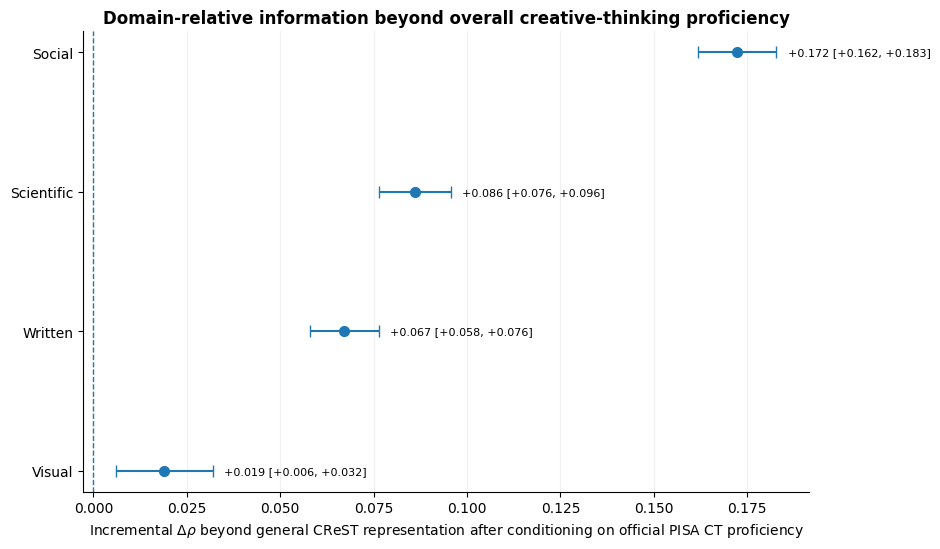

In [ ]:
# Main domain-profile figure beyond overall proficiency

import matplotlib.pyplot as plt


plot_df = (
    profile_bootstrap_summary
    .set_index(
        "domain"
    )
    .loc[
        [
            "Social",
            "Scientific",
            "Written",
            "Visual"
        ]
    ]
    .reset_index()
)


y = np.arange(
    len(
        plot_df
    )
)


x = (
    plot_df[
        "delta_rho_mean"
    ]
    .to_numpy()
)


xerr = np.vstack(
    [
        x
        -
        plot_df[
            "ci_low"
        ].to_numpy(),

        plot_df[
            "ci_high"
        ].to_numpy()
        -
        x
    ]
)


fig, ax = plt.subplots(
    figsize=(
        9.5,
        5.6
    )
)


ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)

ax.set_yticklabels(
    plot_df[
        "domain"
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    r"Incremental $\Delta\rho$ beyond "
    "general CReST representation after conditioning "
    "on official PISA CT proficiency"
)


ax.set_ylabel(
    ""
)


ax.set_title(
    "Domain-relative information beyond overall creative-thinking proficiency",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.18
)

ax.grid(
    axis="y",
    visible=False
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


for i, row in plot_df.iterrows():

    ax.annotate(
        (
            f"{row['delta_rho_mean']:+.3f} "
            f"[{row['ci_low']:+.3f}, "
            f"{row['ci_high']:+.3f}]"
        ),
        (
            row[
                "ci_high"
            ],
            i
        ),
        xytext=(
            8,
            0
        ),
        textcoords="offset points",
        va="center",
        fontsize=8
    )


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_domain_profile_beyond_overall_proficiency.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_domain_profile_beyond_overall_proficiency.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Paired system-bootstrap comparisons between domain increments

DOMAIN_PAIR_BOOT_SEED = 20261017
N_DOMAIN_PAIR_BOOT = 10000

rng_domain_pair = np.random.default_rng(
    DOMAIN_PAIR_BOOT_SEED
)


# One delta-rho value per system × domain

domain_wide = (

    system_domain_profile

    .pivot(
        index="country",
        columns="domain",
        values="delta_rho"
    )

    .loc[
        :,
        [
            "Written",
            "Visual",
            "Social",
            "Scientific"
        ]
    ]
)


assert len(
    domain_wide
) == 63


assert (
    domain_wide
    .notna()
    .all()
    .all()
)


PAIR_SPECS = [

    (
        "Social",
        "Scientific"
    ),

    (
        "Social",
        "Written"
    ),

    (
        "Social",
        "Visual"
    ),

    (
        "Scientific",
        "Written"
    ),

    (
        "Scientific",
        "Visual"
    ),

    (
        "Written",
        "Visual"
    )
]


pair_rows = []


for domain_A, domain_B in PAIR_SPECS:

    # Difference = A - B
    diff = (

        domain_wide[
            domain_A
        ].to_numpy(
            dtype=float
        )

        -

        domain_wide[
            domain_B
        ].to_numpy(
            dtype=float
        )
    )


    boot = np.empty(
        N_DOMAIN_PAIR_BOOT,
        dtype=float
    )


    for b in range(
        N_DOMAIN_PAIR_BOOT
    ):

        idx = rng_domain_pair.integers(
            0,
            len(
                diff
            ),
            size=len(
                diff
            )
        )


        boot[
            b
        ] = (
            diff[
                idx
            ].mean()
        )


    pair_rows.append(
        {
            "domain_A":
                domain_A,

            "domain_B":
                domain_B,

            "contrast":
                f"{domain_A} minus {domain_B}",

            "n_systems":
                len(
                    diff
                ),

            "mean_difference":
                float(
                    diff.mean()
                ),

            "median_difference":
                float(
                    np.median(
                        diff
                    )
                ),

            "ci_low":
                float(
                    np.quantile(
                        boot,
                        0.025
                    )
                ),

            "ci_high":
                float(
                    np.quantile(
                        boot,
                        0.975
                    )
                ),

            "systems_A_greater_B":
                int(
                    (
                        diff > 0
                    ).sum()
                ),

            "pct_systems_A_greater_B":
                float(
                    100.0
                    *
                    np.mean(
                        diff > 0
                    )
                )
        }
    )


domain_pairwise_df = pd.DataFrame(
    pair_rows
)


domain_pairwise_df.to_csv(

    PROFILE_DIR
    / "crest_profile_domain_pairwise_bootstrap.csv",

    index=False
)


print(
    domain_pairwise_df.to_string(
        index=False
    )
)

  domain_A   domain_B                 contrast  n_systems  mean_difference  median_difference   ci_low  ci_high  systems_A_greater_B  pct_systems_A_greater_B
    Social Scientific  Social minus Scientific         63         0.086342           0.084247 0.071815 0.099881                   58                92.063492
    Social    Written     Social minus Written         63         0.105193           0.100925 0.092667 0.117732                   62                98.412698
    Social     Visual      Social minus Visual         63         0.153483           0.168047 0.136369 0.169910                   59                93.650794
Scientific    Written Scientific minus Written         63         0.018851           0.016655 0.005312 0.032591                   41                65.079365
Scientific     Visual  Scientific minus Visual         63         0.067141           0.062872 0.053028 0.081499                   58                92.063492
   Written     Visual     Written minus Visual      

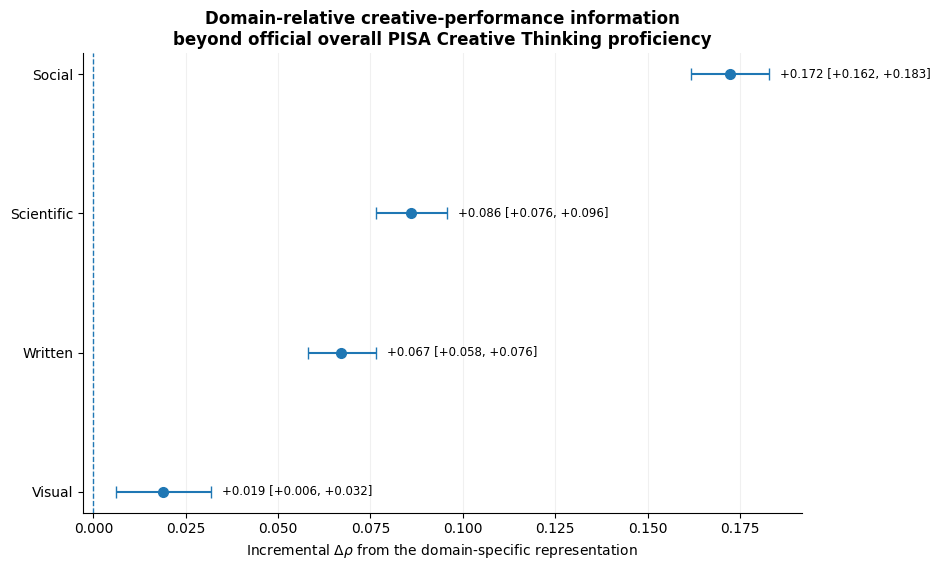

In [ ]:
# Main profile-structure figure beyond overall proficiency

import matplotlib.pyplot as plt


plot_order = [
    "Social",
    "Scientific",
    "Written",
    "Visual"
]


plot_df = (
    profile_bootstrap_summary
    .set_index(
        "domain"
    )
    .loc[
        plot_order
    ]
    .reset_index()
)


y = np.arange(
    len(
        plot_df
    )
)


x = (
    plot_df[
        "delta_rho_mean"
    ]
    .to_numpy()
)


xerr = np.vstack(
    [
        x
        -
        plot_df[
            "ci_low"
        ].to_numpy(),

        plot_df[
            "ci_high"
        ].to_numpy()
        -
        x
    ]
)


fig, ax = plt.subplots(
    figsize=(
        9.5,
        5.8
    )
)


ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df[
        "domain"
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    r"Incremental $\Delta\rho$ from the domain-specific "
    "representation"
)


ax.set_ylabel(
    ""
)


ax.set_title(
    "Domain-relative creative-performance information\n"
    "beyond official overall PISA Creative Thinking proficiency",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.18
)

ax.grid(
    axis="y",
    visible=False
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


for i, row in plot_df.iterrows():

    ax.annotate(
        (
            f"{row['delta_rho_mean']:+.3f} "
            f"[{row['ci_low']:+.3f}, "
            f"{row['ci_high']:+.3f}]"
        ),
        (
            row[
                "ci_high"
            ],
            i
        ),
        xytext=(
            8,
            0
        ),
        textcoords="offset points",
        va="center",
        fontsize=8.5
    )


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_domain_profile_beyond_pisa_proficiency.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_domain_profile_beyond_pisa_proficiency.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Locked profile-structure findings

profile_locked = (

    profile_bootstrap_summary[
        [
            "domain",
            "n_systems",
            "general_rho_mean",
            "domain_rho_mean",
            "combined_rho_mean",
            "delta_rho_mean",
            "ci_low",
            "ci_high",
            "systems_positive_delta",
            "pct_systems_positive_delta"
        ]
    ]

    .copy()
)


interpretation_map = {

    "Social":
        (
            "Strong and universally positive domain-relative "
            "information beyond overall proficiency"
        ),

    "Scientific":
        (
            "Moderate and universally positive domain-relative "
            "information beyond overall proficiency"
        ),

    "Written":
        (
            "Moderate-to-small but highly consistent domain-relative "
            "information beyond overall proficiency"
        ),

    "Visual":
        (
            "Small average increment with substantial cross-system "
            "heterogeneity; interpretation limited by sparse visual items"
        )
}


profile_locked[
    "interpretation"
] = (
    profile_locked[
        "domain"
    ]
    .map(
        interpretation_map
    )
)


profile_locked = (

    profile_locked
    .set_index(
        "domain"
    )
    .loc[
        [
            "Social",
            "Scientific",
            "Written",
            "Visual"
        ]
    ]
    .reset_index()
)


profile_locked.to_csv(

    PROFILE_DIR
    / "crest_profile_beyond_overall_proficiency_LOCKED.csv",

    index=False
)


print(
    profile_locked.to_string(
        index=False
    )
)


print(
    "\nPAIRWISE DOMAIN ORDERING"
)

print(
    "=" * 80
)

print(
    domain_pairwise_df.to_string(
        index=False
    )
)

    domain  n_systems  general_rho_mean  domain_rho_mean  combined_rho_mean  delta_rho_mean   ci_low  ci_high  systems_positive_delta  pct_systems_positive_delta                                                                                                     interpretation
    Social         63          0.158117         0.330542           0.330444        0.172327 0.161755 0.182846                      63                  100.000000                             Strong and universally positive domain-relative information beyond overall proficiency
Scientific         63          0.122443         0.213983           0.208427        0.085985 0.076448 0.095677                      63                  100.000000                           Moderate and universally positive domain-relative information beyond overall proficiency
   Written         63          0.127357         0.194402           0.194491        0.067134 0.058000 0.076428                      61                   96.825397        